In [5]:
# ============================================================
# TRACK 3 — TASK 2
# PROPOSED MODEL NOTEBOOK
#
# Custom CNN + CBAM
# Uses the LOCKED splits produced by the baseline notebook.
# ============================================================

import os
import json
import time
import random
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Locked configuration
# ------------------------------------------------------------

IMG_HEIGHT = 224
IMG_WIDTH = 224
CHANNELS = 3
BATCH_SIZE = 32

IMAGE_SIZE = (IMG_HEIGHT, IMG_WIDTH)
AUTOTUNE = tf.data.AUTOTUNE

MAX_EPOCHS = 25
INITIAL_LR = 1e-3

EARLY_STOPPING_PATIENCE = 5
LR_PATIENCE = 2
LR_REDUCTION_FACTOR = 0.5
MIN_LR = 1e-6

# ------------------------------------------------------------
# New proposed-model output directory
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "/kaggle/working/task2_proposed_outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 88)
print("TRACK 3 — TASK 2 — PROPOSED CNN + CBAM")
print("=" * 88)

print("\nTensorFlow :", tf.__version__)
print("Input      :", f"{IMG_HEIGHT}×{IMG_WIDTH}×{CHANNELS}")
print("Batch size :", BATCH_SIZE)

gpus = tf.config.list_physical_devices("GPU")

print("\nGPU(s):")
for gpu in gpus:
    print(" -", gpu)

# ============================================================
# FIND REQUIRED FILES FROM BASELINE NOTEBOOK OUTPUT
# ============================================================

KAGGLE_INPUT = Path("/kaggle/input")

def find_required_file(filename):

    matches = list(
        KAGGLE_INPUT.rglob(filename)
    )

    if len(matches) == 0:
        raise FileNotFoundError(
            f"\nCould not find: {filename}\n"
            "Attach the baseline notebook output "
            "to this proposed-model notebook."
        )

    if len(matches) > 1:
        print(
            f"WARNING: Multiple matches found for {filename}."
        )
        for m in matches:
            print(" -", m)

    return matches[0]


TRAIN_CSV = find_required_file(
    "FINAL_train_split.csv"
)

VAL_CSV = find_required_file(
    "FINAL_validation_split.csv"
)

TEST_CSV = find_required_file(
    "FINAL_test_split.csv"
)

CLASS_MAPPING_JSON = find_required_file(
    "final_class_mapping.json"
)

print("\nLocked baseline artifacts found:")

print("Train :", TRAIN_CSV)
print("Val   :", VAL_CSV)
print("Test  :", TEST_CSV)
print("Map   :", CLASS_MAPPING_JSON)

print("\nSETUP CELL PASSED ✓")

TRACK 3 — TASK 2 — PROPOSED CNN + CBAM

TensorFlow : 2.20.0
Input      : 224×224×3
Batch size : 32

GPU(s):
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
 - PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')

Locked baseline artifacts found:
Train : /kaggle/input/datasets/sadmantayef/baseline/FINAL_train_split.csv
Val   : /kaggle/input/datasets/sadmantayef/baseline/FINAL_validation_split.csv
Test  : /kaggle/input/datasets/sadmantayef/baseline/FINAL_test_split.csv
Map   : /kaggle/input/datasets/sadmantayef/baseline/final_class_mapping.json

SETUP CELL PASSED ✓


In [6]:
# ============================================================
# CELL 2
# LOAD THE EXACT LOCKED TASK 2 SPLITS
#
# DO NOT regenerate the split in this notebook.
# ============================================================

print("=" * 88)
print("LOADING LOCKED TASK 2 DATA PARTITIONS")
print("=" * 88)

train_df = pd.read_csv(
    TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)

test_df = pd.read_csv(
    TEST_CSV
)

with open(
    CLASS_MAPPING_JSON,
    "r"
) as f:

    class_mapping_raw = json.load(f)

# JSON keys become strings
class_mapping = {
    int(k): v
    for k, v
    in class_mapping_raw.items()
}

class_names = [
    class_mapping[i]
    for i in sorted(class_mapping)
]

NUM_CLASSES = len(
    class_names
)

print("\nLocked dataset:")
print(
    f"Training   : {len(train_df):,}"
)
print(
    f"Validation : {len(val_df):,}"
)
print(
    f"Testing    : {len(test_df):,}"
)
print(
    f"Classes    : {NUM_CLASSES}"
)

assert NUM_CLASSES == 24

# ------------------------------------------------------------
# Verify every split has all classes
# ------------------------------------------------------------

expected = set(
    range(NUM_CLASSES)
)

assert set(
    train_df["label"].unique()
) == expected

assert set(
    val_df["label"].unique()
) == expected

assert set(
    test_df["label"].unique()
) == expected

# ------------------------------------------------------------
# Verify exact-content hashes remain non-overlapping
# ------------------------------------------------------------

assert "pixel_hash" in train_df.columns
assert "pixel_hash" in val_df.columns
assert "pixel_hash" in test_df.columns

train_hashes = set(
    train_df["pixel_hash"]
)

val_hashes = set(
    val_df["pixel_hash"]
)

test_hashes = set(
    test_df["pixel_hash"]
)

train_val_overlap = (
    train_hashes & val_hashes
)

train_test_overlap = (
    train_hashes & test_hashes
)

val_test_overlap = (
    val_hashes & test_hashes
)

print("\nCONTENT LEAKAGE CHECK")
print("-" * 88)

print(
    "Train ↔ Validation:",
    len(train_val_overlap)
)

print(
    "Train ↔ Test      :",
    len(train_test_overlap)
)

print(
    "Validation ↔ Test :",
    len(val_test_overlap)
)

assert len(train_val_overlap) == 0
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

print("\n✓ Same locked Task 2 split loaded.")
print("✓ 24 evaluated malware families.")
print("✓ Exact-content overlap = 0 / 0 / 0.")

print("\nLOCKED DATA LOAD: PASSED ✓")

LOADING LOCKED TASK 2 DATA PARTITIONS

Locked dataset:
Training   : 5,612
Validation : 1,203
Testing    : 1,203
Classes    : 24

CONTENT LEAKAGE CHECK
----------------------------------------------------------------------------------------
Train ↔ Validation: 0
Train ↔ Test      : 0
Validation ↔ Test : 0

✓ Same locked Task 2 split loaded.
✓ 24 evaluated malware families.
✓ Exact-content overlap = 0 / 0 / 0.

LOCKED DATA LOAD: PASSED ✓


In [7]:
# ============================================================
# CELL 3
# TENSORFLOW PIPELINE FOR PROPOSED MODEL
# ============================================================

print("=" * 88)
print("PROPOSED MODEL — TENSORFLOW INPUT PIPELINE")
print("=" * 88)

def load_image(
    filepath,
    label
):

    image_bytes = tf.io.read_file(
        filepath
    )

    image = tf.io.decode_image(
        image_bytes,
        channels=1,
        expand_animations=False
    )

    image.set_shape(
        [None, None, 1]
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        method="bilinear"
    )

    image = (
        image / 255.0
    )

    image = tf.image.grayscale_to_rgb(
        image
    )

    image.set_shape(
        [
            IMG_HEIGHT,
            IMG_WIDTH,
            CHANNELS
        ]
    )

    label = tf.cast(
        label,
        tf.int32
    )

    return image, label


def create_tf_dataset(
    dataframe,
    training=False
):

    paths = (
        dataframe["filepath"]
        .astype(str)
        .values
    )

    labels = (
        dataframe["label"]
        .astype(np.int32)
        .values
    )

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:

        ds = ds.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(
        BATCH_SIZE
    )

    ds = ds.prefetch(
        AUTOTUNE
    )

    return ds


train_ds = create_tf_dataset(
    train_df,
    training=True
)

val_ds = create_tf_dataset(
    val_df
)

test_ds = create_tf_dataset(
    test_df
)

sample_images, sample_labels = next(
    iter(train_ds)
)

print("\nImage batch :", sample_images.shape)
print("Label batch :", sample_labels.shape)

print(
    "Pixel range :",
    float(tf.reduce_min(sample_images)),
    "to",
    float(tf.reduce_max(sample_images))
)

assert sample_images.shape[1:] == (
    224,
    224,
    3
)

print("\nTENSORFLOW PIPELINE: PASSED ✓")

PROPOSED MODEL — TENSORFLOW INPUT PIPELINE

Image batch : (32, 224, 224, 3)
Label batch : (32,)
Pixel range : 0.0 to 1.0

TENSORFLOW PIPELINE: PASSED ✓


In [8]:
# ============================================================
# CELL 4
# CLASS WEIGHTS + CONSERVATIVE AUGMENTATION
# ============================================================

print("=" * 88)
print("CLASS WEIGHTS + AUGMENTATION")
print("=" * 88)

# ============================================================
# CLASS WEIGHTS
# ============================================================

y_train = (
    train_df["label"]
    .astype(np.int32)
    .values
)

classes = np.arange(
    NUM_CLASSES
)

weight_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(c): float(w)
    for c, w in zip(
        classes,
        weight_values
    )
}

print(
    f"\nClass weights created for "
    f"{len(class_weights)} classes."
)

# ============================================================
# AUGMENTATION
# ============================================================

def create_augmentation():

    return tf.keras.Sequential(
        [

            tf.keras.layers.RandomTranslation(
                height_factor=0.02,
                width_factor=0.02,
                fill_mode="reflect",
                seed=SEED
            ),

            tf.keras.layers.RandomZoom(
                height_factor=(-0.05, 0.05),
                width_factor=(-0.05, 0.05),
                fill_mode="reflect",
                seed=SEED + 1
            ),

            tf.keras.layers.RandomContrast(
                factor=0.05,
                seed=SEED + 2
            )

        ],
        name="malimg_augmentation"
    )


test_aug = create_augmentation()

augmented = test_aug(
    sample_images,
    training=True
)

unchanged = test_aug(
    sample_images,
    training=False
)

assert augmented.shape == sample_images.shape

assert float(
    tf.reduce_max(
        tf.abs(
            sample_images -
            unchanged
        )
    )
) < 1e-6

print("✓ Same augmentation policy restored.")
print("✓ Validation/test augmentation disabled.")
print("✓ Class weights calculated from training only.")

print("\nCLASS WEIGHTS + AUGMENTATION: PASSED ✓")

CLASS WEIGHTS + AUGMENTATION

Class weights created for 24 classes.
✓ Same augmentation policy restored.
✓ Validation/test augmentation disabled.
✓ Class weights calculated from training only.

CLASS WEIGHTS + AUGMENTATION: PASSED ✓


In [9]:
# ============================================================
# CELL 5
# PROPOSED MODEL — COMMON TRAINING + EVALUATION ENGINE
# ============================================================

print("=" * 88)
print("PROPOSED MODEL — TRAINING + EVALUATION ENGINE")
print("=" * 88)

import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Proposed-model output folder
# ------------------------------------------------------------

PROPOSED_MODEL_NAME = "CustomCNN_CBAM"

MODEL_OUTPUT_DIR = (
    OUTPUT_DIR /
    PROPOSED_MODEL_NAME
)

MODEL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ============================================================
# CALLBACKS
# ============================================================

def create_callbacks():

    checkpoint_path = (
        MODEL_OUTPUT_DIR /
        "CustomCNN_CBAM_best.keras"
    )

    callbacks = [

        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            verbose=1
        ),

        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=LR_REDUCTION_FACTOR,
            patience=LR_PATIENCE,
            min_lr=MIN_LR,
            verbose=1
        )
    ]

    return callbacks


# ============================================================
# COMPILE MODEL
# ============================================================

def compile_proposed_model(model):

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=INITIAL_LR
        ),

        loss=tf.keras.losses.SparseCategoricalCrossentropy(),

        metrics=["accuracy"]
    )

    return model


# ============================================================
# PARAMETER COUNT
# ============================================================

def get_parameter_counts(model):

    total_params = int(
        model.count_params()
    )

    trainable_params = int(
        np.sum([
            np.prod(v.shape)
            for v in model.trainable_weights
        ])
    )

    non_trainable_params = (
        total_params -
        trainable_params
    )

    return {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "non_trainable_params": non_trainable_params
    }


# ============================================================
# TRAINING CURVES
# ============================================================

def save_training_curves(
    history,
    model_name
):

    # Accuracy
    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.title(
        f"{model_name} — Accuracy"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    accuracy_path = (
        MODEL_OUTPUT_DIR /
        f"{model_name}_accuracy_curve.png"
    )

    plt.savefig(
        accuracy_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # Loss
    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title(
        f"{model_name} — Loss"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    loss_path = (
        MODEL_OUTPUT_DIR /
        f"{model_name}_loss_curve.png"
    )

    plt.savefig(
        loss_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# TEST PREDICTION + INFERENCE TIME
# ============================================================

def predict_test_set(model):

    # GPU warm-up
    warmup_images, _ = next(
        iter(test_ds)
    )

    _ = model(
        warmup_images,
        training=False
    )

    # Timed inference
    start = time.perf_counter()

    probabilities = model.predict(
        test_ds,
        verbose=1
    )

    end = time.perf_counter()

    inference_seconds = (
        end - start
    )

    y_pred = np.argmax(
        probabilities,
        axis=1
    )

    ms_per_image = (
        inference_seconds /
        len(test_df)
    ) * 1000

    return (
        probabilities,
        y_pred,
        inference_seconds,
        ms_per_image
    )


# ============================================================
# FULL TEST EVALUATION
# ============================================================

def evaluate_proposed_model(
    model,
    history,
    training_seconds
):

    print("\n" + "=" * 88)
    print("FULL TEST EVALUATION — CUSTOM CNN + CBAM")
    print("=" * 88)

    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    y_true = (
        test_df["label"]
        .astype(np.int32)
        .values
    )

    (
        probabilities,
        y_pred,
        inference_seconds,
        ms_per_image
    ) = predict_test_set(
        model
    )

    assert len(
        y_true
    ) == len(
        y_pred
    )

    # ========================================================
    # GLOBAL METRICS
    # ========================================================

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(
            range(NUM_CLASSES)
        ),
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = (
        pd.DataFrame(
            report_dict
        )
        .transpose()
    )

    report_path = (
        MODEL_OUTPUT_DIR /
        "CustomCNN_CBAM_classification_report.csv"
    )

    report_df.to_csv(
        report_path
    )

    # ========================================================
    # PER-CLASS METRICS
    # ========================================================

    per_class_df = report_df.loc[
        class_names,
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ].copy()

    per_class_df.index.name = "family"

    per_class_path = (
        MODEL_OUTPUT_DIR /
        "CustomCNN_CBAM_per_class_metrics.csv"
    )

    per_class_df.to_csv(
        per_class_path
    )

    lowest_recall_df = (
        per_class_df
        .sort_values(
            "recall",
            ascending=True
        )
    )

    lowest_recall_path = (
        MODEL_OUTPUT_DIR /
        "CustomCNN_CBAM_recall_sorted.csv"
    )

    lowest_recall_df.to_csv(
        lowest_recall_path
    )

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(
            range(NUM_CLASSES)
        )
    )

    cm_df = pd.DataFrame(
        cm,
        index=class_names,
        columns=class_names
    )

    cm_csv_path = (
        MODEL_OUTPUT_DIR /
        "CustomCNN_CBAM_confusion_matrix.csv"
    )

    cm_df.to_csv(
        cm_csv_path
    )

    plt.figure(
        figsize=(15, 13)
    )

    plt.imshow(
        cm,
        interpolation="nearest"
    )

    plt.title(
        "Custom CNN + CBAM — Confusion Matrix"
    )

    plt.colorbar()

    ticks = np.arange(
        NUM_CLASSES
    )

    plt.xticks(
        ticks,
        class_names,
        rotation=90,
        fontsize=8
    )

    plt.yticks(
        ticks,
        class_names,
        fontsize=8
    )

    plt.xlabel(
        "Predicted Family"
    )

    plt.ylabel(
        "True Family"
    )

    plt.tight_layout()

    cm_image_path = (
        MODEL_OUTPUT_DIR /
        "CustomCNN_CBAM_confusion_matrix.png"
    )

    plt.savefig(
        cm_image_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ========================================================
    # TEST PREDICTIONS
    # ========================================================

    prediction_df = pd.DataFrame({

        "filepath":
            test_df["filepath"].values,

        "true_label":
            y_true,

        "true_family": [
            class_names[x]
            for x in y_true
        ],

        "predicted_label":
            y_pred,

        "predicted_family": [
            class_names[x]
            for x in y_pred
        ],

        "correct":
            y_true == y_pred
    })

    prediction_path = (
        MODEL_OUTPUT_DIR /
        "CustomCNN_CBAM_test_predictions.csv"
    )

    prediction_df.to_csv(
        prediction_path,
        index=False
    )

    # ========================================================
    # PARAMETERS + MODEL SIZE
    # ========================================================

    params = get_parameter_counts(
        model
    )

    model_path = (
        MODEL_OUTPUT_DIR /
        "CustomCNN_CBAM_final.keras"
    )

    model.save(
        model_path
    )

    model_size_mb = (
        os.path.getsize(
            model_path
        )
        / (1024 ** 2)
    )

    epochs_completed = len(
        history.history["loss"]
    )

    # ========================================================
    # FINAL RESULT
    # ========================================================

    result = {

        "model":
            "CustomCNN_CBAM",

        "accuracy":
            float(accuracy),

        "macro_precision":
            float(macro_precision),

        "macro_recall":
            float(macro_recall),

        "macro_f1":
            float(macro_f1),

        "weighted_precision":
            float(weighted_precision),

        "weighted_recall":
            float(weighted_recall),

        "weighted_f1":
            float(weighted_f1),

        "training_time_seconds":
            float(training_seconds),

        "training_time_minutes":
            float(
                training_seconds / 60
            ),

        "epochs_completed":
            int(epochs_completed),

        "total_params":
            int(
                params["total_params"]
            ),

        "trainable_params":
            int(
                params["trainable_params"]
            ),

        "non_trainable_params":
            int(
                params["non_trainable_params"]
            ),

        "model_size_mb":
            float(model_size_mb),

        "test_inference_seconds":
            float(inference_seconds),

        "inference_ms_per_image":
            float(ms_per_image)
    }

    metrics_path = (
        MODEL_OUTPUT_DIR /
        "CustomCNN_CBAM_metrics.json"
    )

    with open(
        metrics_path,
        "w"
    ) as f:

        json.dump(
            result,
            f,
            indent=4
        )

    # ========================================================
    # DISPLAY
    # ========================================================

    print("\nGLOBAL TEST METRICS")
    print("-" * 82)

    print(
        f"Accuracy           : {accuracy:.4f}"
    )

    print(
        f"Macro Precision    : {macro_precision:.4f}"
    )

    print(
        f"Macro Recall       : {macro_recall:.4f}"
    )

    print(
        f"Macro F1           : {macro_f1:.4f}"
    )

    print(
        f"Weighted Precision : {weighted_precision:.4f}"
    )

    print(
        f"Weighted Recall    : {weighted_recall:.4f}"
    )

    print(
        f"Weighted F1        : {weighted_f1:.4f}"
    )

    print("\nEFFICIENCY")
    print("-" * 82)

    print(
        f"Training time      : "
        f"{training_seconds / 60:.2f} min"
    )

    print(
        f"Epochs completed   : "
        f"{epochs_completed}"
    )

    print(
        f"Total parameters   : "
        f"{params['total_params']:,}"
    )

    print(
        f"Model size         : "
        f"{model_size_mb:.2f} MB"
    )

    print(
        f"Inference          : "
        f"{ms_per_image:.4f} ms/image"
    )

    print("\nLOWEST PER-CLASS RECALL")
    print("-" * 82)

    print(
        lowest_recall_df.head(
            10
        ).to_string()
    )

    return (
        result,
        report_df,
        per_class_df,
        prediction_df
    )


# ============================================================
# TRAIN + EVALUATE WRAPPER
# ============================================================

def run_proposed_experiment(model):

    model = compile_proposed_model(
        model
    )

    model.summary()

    callbacks = create_callbacks()

    start = time.perf_counter()

    history = model.fit(

        train_ds,

        validation_data=val_ds,

        epochs=MAX_EPOCHS,

        class_weight=class_weights,

        callbacks=callbacks,

        verbose=1
    )

    end = time.perf_counter()

    training_seconds = (
        end - start
    )

    print(
        f"\nTraining completed in "
        f"{training_seconds / 60:.2f} minutes."
    )

    save_training_curves(
        history,
        PROPOSED_MODEL_NAME
    )

    (
        result,
        report_df,
        per_class_df,
        prediction_df
    ) = evaluate_proposed_model(
        model=model,
        history=history,
        training_seconds=training_seconds
    )

    return (
        model,
        history,
        result,
        report_df,
        per_class_df,
        prediction_df
    )


print("\n" + "=" * 88)
print("PROPOSED MODEL TRAINING ENGINE READY ✓")
print("=" * 88)

PROPOSED MODEL — TRAINING + EVALUATION ENGINE

PROPOSED MODEL TRAINING ENGINE READY ✓


In [10]:
# ============================================================
# CELL 6
# CBAM ATTENTION MODULE
#
# Channel Attention → Spatial Attention
# ============================================================

print("=" * 88)
print("CBAM ATTENTION MODULE")
print("=" * 88)


@tf.keras.utils.register_keras_serializable(
    package="Task2"
)
class ChannelAttention(
    tf.keras.layers.Layer
):

    def __init__(
        self,
        reduction_ratio=8,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.reduction_ratio = (
            reduction_ratio
        )


    def build(
        self,
        input_shape
    ):

        channels = int(
            input_shape[-1]
        )

        reduced_channels = max(
            channels
            // self.reduction_ratio,
            1
        )

        # Shared MLP
        self.fc1 = (
            tf.keras.layers.Dense(
                reduced_channels,
                activation="relu",
                use_bias=True,
                name="channel_reduce"
            )
        )

        self.fc2 = (
            tf.keras.layers.Dense(
                channels,
                activation=None,
                use_bias=True,
                name="channel_expand"
            )
        )

        super().build(
            input_shape
        )


    def call(
        self,
        inputs
    ):

        # Global average pooling
        avg_pool = tf.reduce_mean(
            inputs,
            axis=[1, 2]
        )

        # Global max pooling
        max_pool = tf.reduce_max(
            inputs,
            axis=[1, 2]
        )

        # Shared MLP
        avg_out = self.fc2(
            self.fc1(
                avg_pool
            )
        )

        max_out = self.fc2(
            self.fc1(
                max_pool
            )
        )

        # Channel-attention weights
        attention = tf.nn.sigmoid(
            avg_out + max_out
        )

        attention = tf.expand_dims(
            attention,
            axis=1
        )

        attention = tf.expand_dims(
            attention,
            axis=1
        )

        return (
            inputs * attention
        )


    def get_config(self):

        config = super().get_config()

        config.update({
            "reduction_ratio":
                self.reduction_ratio
        })

        return config


@tf.keras.utils.register_keras_serializable(
    package="Task2"
)
class SpatialAttention(
    tf.keras.layers.Layer
):

    def __init__(
        self,
        kernel_size=7,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.kernel_size = (
            kernel_size
        )

        self.conv = (
            tf.keras.layers.Conv2D(
                filters=1,
                kernel_size=kernel_size,
                strides=1,
                padding="same",
                activation="sigmoid",
                use_bias=False,
                name="spatial_attention_conv"
            )
        )


    def call(
        self,
        inputs
    ):

        # Average feature map
        avg_map = tf.reduce_mean(
            inputs,
            axis=-1,
            keepdims=True
        )

        # Maximum feature map
        max_map = tf.reduce_max(
            inputs,
            axis=-1,
            keepdims=True
        )

        combined = tf.concat(
            [
                avg_map,
                max_map
            ],
            axis=-1
        )

        attention = self.conv(
            combined
        )

        return (
            inputs * attention
        )


    def get_config(self):

        config = super().get_config()

        config.update({
            "kernel_size":
                self.kernel_size
        })

        return config


@tf.keras.utils.register_keras_serializable(
    package="Task2"
)
class CBAM(
    tf.keras.layers.Layer
):

    def __init__(
        self,
        reduction_ratio=8,
        spatial_kernel_size=7,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.reduction_ratio = (
            reduction_ratio
        )

        self.spatial_kernel_size = (
            spatial_kernel_size
        )

        self.channel_attention = (
            ChannelAttention(
                reduction_ratio=
                    reduction_ratio,
                name="channel_attention"
            )
        )

        self.spatial_attention = (
            SpatialAttention(
                kernel_size=
                    spatial_kernel_size,
                name="spatial_attention"
            )
        )


    def call(
        self,
        inputs
    ):

        x = self.channel_attention(
            inputs
        )

        x = self.spatial_attention(
            x
        )

        return x


    def get_config(self):

        config = super().get_config()

        config.update({

            "reduction_ratio":
                self.reduction_ratio,

            "spatial_kernel_size":
                self.spatial_kernel_size
        })

        return config


print("\nCBAM configuration:")
print("Channel attention   : Enabled")
print("Spatial attention   : Enabled")
print("Reduction ratio     : 8")
print("Spatial kernel      : 7 × 7")
print("Order               : Channel → Spatial")

print("\nCBAM IMPLEMENTATION: PASSED ✓")

CBAM ATTENTION MODULE

CBAM configuration:
Channel attention   : Enabled
Spatial attention   : Enabled
Reduction ratio     : 8
Spatial kernel      : 7 × 7
Order               : Channel → Spatial

CBAM IMPLEMENTATION: PASSED ✓


In [11]:
# ============================================================
# CELL 7
# PROPOSED MODEL — CUSTOM CNN + CBAM
#
# SimpleCNN:
# Block1 → Block2 → Block3 → GAP → Classifier
#
# Proposed:
# Block1 → Block2 → Block3 → CBAM → GAP → Classifier
# ============================================================

print("=" * 88)
print("PROPOSED MODEL — CUSTOM CNN + CBAM")
print("=" * 88)

tf.keras.backend.clear_session()


def conv_block(
    x,
    filters,
    block_name
):

    x = tf.keras.layers.Conv2D(
        filters=filters,
        kernel_size=3,
        padding="same",
        use_bias=False,
        name=f"{block_name}_conv1"
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name=f"{block_name}_bn1"
    )(x)

    x = tf.keras.layers.Activation(
        "relu",
        name=f"{block_name}_relu1"
    )(x)

    x = tf.keras.layers.Conv2D(
        filters=filters,
        kernel_size=3,
        padding="same",
        use_bias=False,
        name=f"{block_name}_conv2"
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name=f"{block_name}_bn2"
    )(x)

    x = tf.keras.layers.Activation(
        "relu",
        name=f"{block_name}_relu2"
    )(x)

    x = tf.keras.layers.MaxPooling2D(
        pool_size=2,
        name=f"{block_name}_pool"
    )(x)

    return x


def build_custom_cnn_cbam():

    inputs = tf.keras.Input(
        shape=(
            IMG_HEIGHT,
            IMG_WIDTH,
            CHANNELS
        ),
        name="input_image"
    )

    # Same augmentation policy as SimpleCNN
    x = create_augmentation()(
        inputs
    )

    # Block 1
    x = conv_block(
        x,
        filters=32,
        block_name="block1"
    )

    # Block 2
    x = conv_block(
        x,
        filters=64,
        block_name="block2"
    )

    # Block 3
    x = conv_block(
        x,
        filters=128,
        block_name="block3"
    )

    # ========================================================
    # CBAM — ONLY MAJOR ARCHITECTURAL ADDITION
    # ========================================================

    x = CBAM(
        reduction_ratio=8,
        spatial_kernel_size=7,
        name="CBAM_attention"
    )(x)

    # Same classifier path as SimpleCNN
    x = tf.keras.layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        name="classifier_dense"
    )(x)

    x = tf.keras.layers.Dropout(
        0.40,
        name="classifier_dropout"
    )(x)

    outputs = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="family_predictions"
    )(x)

    return tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="CustomCNN_CBAM"
    )


custom_cnn_cbam = (
    build_custom_cnn_cbam()
)

custom_cnn_cbam.summary()


# ============================================================
# VERIFY
# ============================================================

dummy_input = tf.zeros(
    (
        1,
        IMG_HEIGHT,
        IMG_WIDTH,
        CHANNELS
    )
)

dummy_output = custom_cnn_cbam(
    dummy_input,
    training=False
)

cbam_layers = [
    layer
    for layer in custom_cnn_cbam.layers
    if isinstance(
        layer,
        CBAM
    )
]

print("\nMODEL VERIFICATION")
print("-" * 88)

print(
    "Input shape      :",
    dummy_input.shape
)

print(
    "Output shape     :",
    dummy_output.shape
)

print(
    "Classes          :",
    NUM_CLASSES
)

print(
    "Total parameters :",
    f"{custom_cnn_cbam.count_params():,}"
)

assert dummy_output.shape == (
    1,
    NUM_CLASSES
)

assert len(
    cbam_layers
) == 1

print("\n✓ Same 3-block CNN backbone.")
print("✓ CBAM present exactly once.")
print("✓ CBAM placed after Block 3.")
print("✓ Channel attention enabled.")
print("✓ Spatial attention enabled.")
print("✓ Output dimension correct.")

print("\nCUSTOM CNN + CBAM: PASSED ✓")

PROPOSED MODEL — CUSTOM CNN + CBAM


Model: "CustomCNN_CBAM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malimg_augmentation             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CBAM_attention (CBAM)           │ (None, 28, 28, 128)    │         4,338 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 312,298 (1.19 MB)

 Trainable params: 311,402 (1.19 MB)

 Non-trainable params: 896 (3.50 KB)


MODEL VERIFICATION
----------------------------------------------------------------------------------------
Input shape      : (1, 224, 224, 3)
Output shape     : (1, 24)
Classes          : 24
Total parameters : 312,298

✓ Same 3-block CNN backbone.
✓ CBAM present exactly once.
✓ CBAM placed after Block 3.
✓ Channel attention enabled.
✓ Spatial attention enabled.
✓ Output dimension correct.

CUSTOM CNN + CBAM: PASSED ✓


GENERATING ARCHITECTURE DIAGRAM


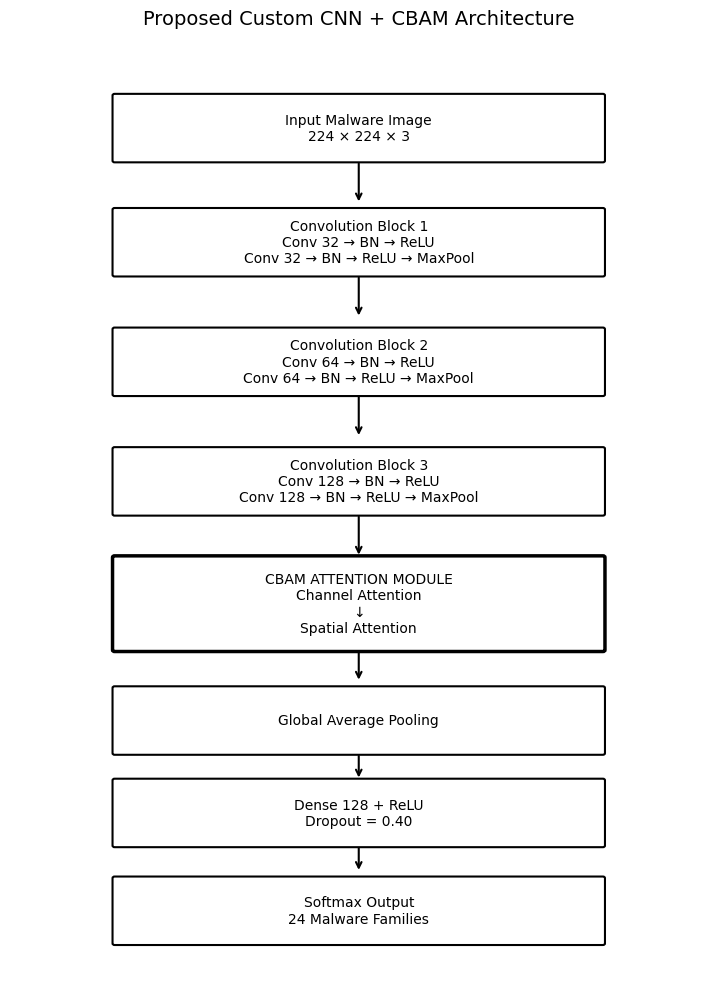


Saved:
/kaggle/working/task2_proposed_outputs/CustomCNN_CBAM_architecture.png

ARCHITECTURE DIAGRAM: COMPLETE ✓


In [12]:
# ============================================================
# CELL 8
# PROPOSED CNN + CBAM ARCHITECTURE DIAGRAM
# ============================================================

print("=" * 88)
print("GENERATING ARCHITECTURE DIAGRAM")
print("=" * 88)

from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(
    figsize=(9, 12)
)

ax.set_xlim(
    0,
    10
)

ax.set_ylim(
    0,
    17
)

ax.axis(
    "off"
)


def draw_box(
    y,
    text,
    height=1.2,
    linewidth=1.5
):

    box = FancyBboxPatch(
        (1.5, y),
        7,
        height,
        boxstyle="round,pad=0.03",
        linewidth=linewidth,
        fill=False
    )

    ax.add_patch(
        box
    )

    ax.text(
        5,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=10
    )


def draw_arrow(
    start,
    end
):

    ax.annotate(
        "",
        xy=(5, end),
        xytext=(5, start),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.5
        )
    )


draw_box(
    15.0,
    "Input Malware Image\n224 × 224 × 3"
)

draw_box(
    12.9,
    "Convolution Block 1\n"
    "Conv 32 → BN → ReLU\n"
    "Conv 32 → BN → ReLU → MaxPool"
)

draw_box(
    10.7,
    "Convolution Block 2\n"
    "Conv 64 → BN → ReLU\n"
    "Conv 64 → BN → ReLU → MaxPool"
)

draw_box(
    8.5,
    "Convolution Block 3\n"
    "Conv 128 → BN → ReLU\n"
    "Conv 128 → BN → ReLU → MaxPool"
)

draw_box(
    6.0,
    "CBAM ATTENTION MODULE\n"
    "Channel Attention\n"
    "↓\n"
    "Spatial Attention",
    height=1.7,
    linewidth=2.5
)

draw_box(
    4.1,
    "Global Average Pooling"
)

draw_box(
    2.4,
    "Dense 128 + ReLU\nDropout = 0.40"
)

draw_box(
    0.6,
    f"Softmax Output\n{NUM_CLASSES} Malware Families"
)

draw_arrow(
    15.0,
    14.2
)

draw_arrow(
    12.9,
    12.1
)

draw_arrow(
    10.7,
    9.9
)

draw_arrow(
    8.5,
    7.7
)

draw_arrow(
    6.0,
    5.4
)

draw_arrow(
    4.1,
    3.6
)

draw_arrow(
    2.4,
    1.9
)

ax.set_title(
    "Proposed Custom CNN + CBAM Architecture",
    fontsize=14,
    pad=20
)

architecture_path = (
    OUTPUT_DIR /
    "CustomCNN_CBAM_architecture.png"
)

plt.savefig(
    architecture_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(architecture_path)

print("\nARCHITECTURE DIAGRAM: COMPLETE ✓")

In [13]:
# ============================================================
# CELL 9
# PROPOSED MODEL SETTINGS / HYPERPARAMETERS
# ============================================================

print("=" * 88)
print("PROPOSED MODEL SETTINGS")
print("=" * 88)

proposed_settings = {

    "model":
        "Custom CNN + CBAM",

    "input_shape":
        [224, 224, 3],

    "evaluated_classes":
        NUM_CLASSES,

    "conv_blocks":
        3,

    "filters":
        [32, 64, 128],

    "convolutions_per_block":
        2,

    "kernel_size":
        "3x3",

    "activation":
        "ReLU",

    "batch_normalization":
        True,

    "pooling":
        "MaxPooling 2x2",

    "attention":
        "CBAM",

    "attention_placement":
        "After convolutional block 3",

    "channel_attention":
        True,

    "channel_reduction_ratio":
        8,

    "spatial_attention":
        True,

    "spatial_kernel_size":
        "7x7",

    "global_pooling":
        "GlobalAveragePooling2D",

    "classifier_dense_units":
        128,

    "dropout":
        0.40,

    "output":
        f"Softmax ({NUM_CLASSES} classes)",

    "optimizer":
        "Adam",

    "initial_learning_rate":
        INITIAL_LR,

    "loss":
        "Sparse Categorical Crossentropy",

    "batch_size":
        BATCH_SIZE,

    "maximum_epochs":
        MAX_EPOCHS,

    "class_weights":
        True,

    "augmentation":
        "Conservative training-only",

    "early_stopping_patience":
        EARLY_STOPPING_PATIENCE,

    "reduce_lr_patience":
        LR_PATIENCE,

    "reduce_lr_factor":
        LR_REDUCTION_FACTOR,

    "primary_metric":
        "Macro-F1",

    "supporting_metric":
        "Per-class Recall"
}

settings_path = (
    OUTPUT_DIR /
    "CustomCNN_CBAM_settings.json"
)

with open(
    settings_path,
    "w"
) as f:

    json.dump(
        proposed_settings,
        f,
        indent=4
    )


settings_df = pd.DataFrame({

    "Setting": [
        "Input",
        "Conv blocks",
        "Filters",
        "Kernel",
        "Attention",
        "Attention placement",
        "Channel reduction ratio",
        "Spatial kernel",
        "Dense units",
        "Dropout",
        "Optimizer",
        "Initial LR",
        "Batch size",
        "Max epochs",
        "Loss",
        "Primary metric"
    ],

    "Value": [
        "224×224×3",
        "3",
        "32 → 64 → 128",
        "3×3",
        "CBAM",
        "After Block 3",
        "8",
        "7×7",
        "128",
        "0.40",
        "Adam",
        str(INITIAL_LR),
        str(BATCH_SIZE),
        str(MAX_EPOCHS),
        "Sparse categorical crossentropy",
        "Macro-F1"
    ]
})

print()
print(
    settings_df.to_string(
        index=False
    )
)

print("\nSaved:")
print(settings_path)

PROPOSED MODEL SETTINGS

                Setting                           Value
                  Input                       224×224×3
            Conv blocks                               3
                Filters                   32 → 64 → 128
                 Kernel                             3×3
              Attention                            CBAM
    Attention placement                   After Block 3
Channel reduction ratio                               8
         Spatial kernel                             7×7
            Dense units                             128
                Dropout                            0.40
              Optimizer                            Adam
             Initial LR                           0.001
             Batch size                              32
             Max epochs                              25
                   Loss Sparse categorical crossentropy
         Primary metric                        Macro-F1

Saved:
/kaggle/working

TRAINING PROPOSED MODEL — CUSTOM CNN + CBAM


Model: "CustomCNN_CBAM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malimg_augmentation             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CBAM_attention (CBAM)           │ (None, 28, 28, 128)    │         4,338 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 312,298 (1.19 MB)

 Trainable params: 311,402 (1.19 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.3493 - loss: 2.3680
Epoch 1: val_loss improved from None to 17.91424, saving model to /kaggle/working/task2_proposed_outputs/CustomCNN_CBAM/CustomCNN_CBAM_best.keras

Epoch 1: finished saving model to /kaggle/working/task2_proposed_outputs/CustomCNN_CBAM/CustomCNN_CBAM_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 63s 287ms/step - accuracy: 0.5123 - loss: 1.8970 - val_accuracy: 0.0208 - val_loss: 17.9142 - learning_rate: 0.0010
Epoch 2/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.7817 - loss: 0.8600
Epoch 2: val_loss improved from 17.91424 to 15.76578, saving model to /kaggle/working/task2_proposed_outputs/CustomCNN_CBAM/CustomCNN_CBAM_best.keras

Epoch 2: finished saving model to /kaggle/working/task2_proposed_outputs/CustomCNN_CBAM/CustomCNN_CBAM_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 48s 273ms/step - accuracy: 0.7988 - loss: 0.7215 - val_accuracy: 0.0241 - val_loss: 15.7658 - learning_rate: 0.0010
Epoch 3/

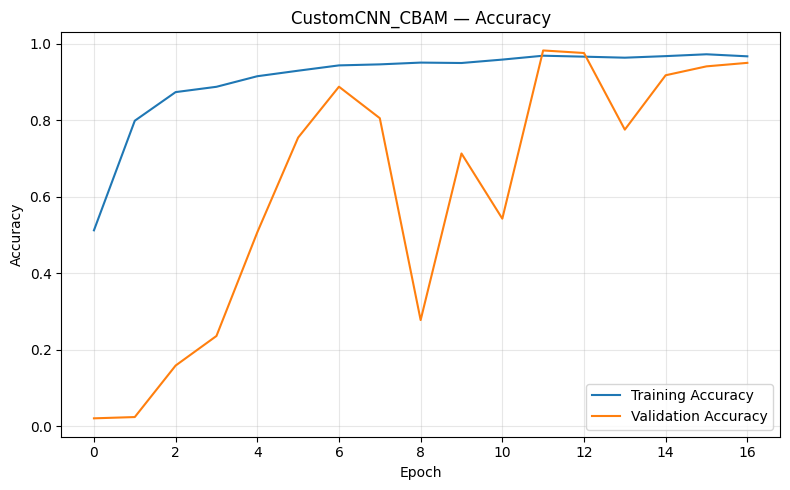

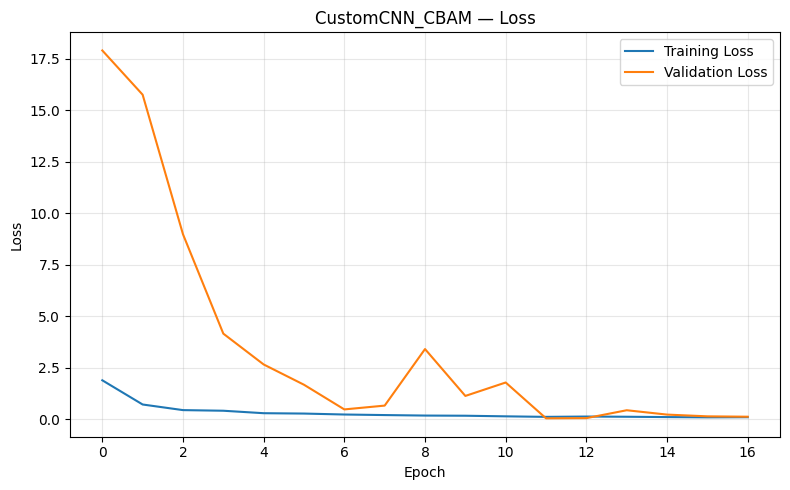


FULL TEST EVALUATION — CUSTOM CNN + CBAM
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step


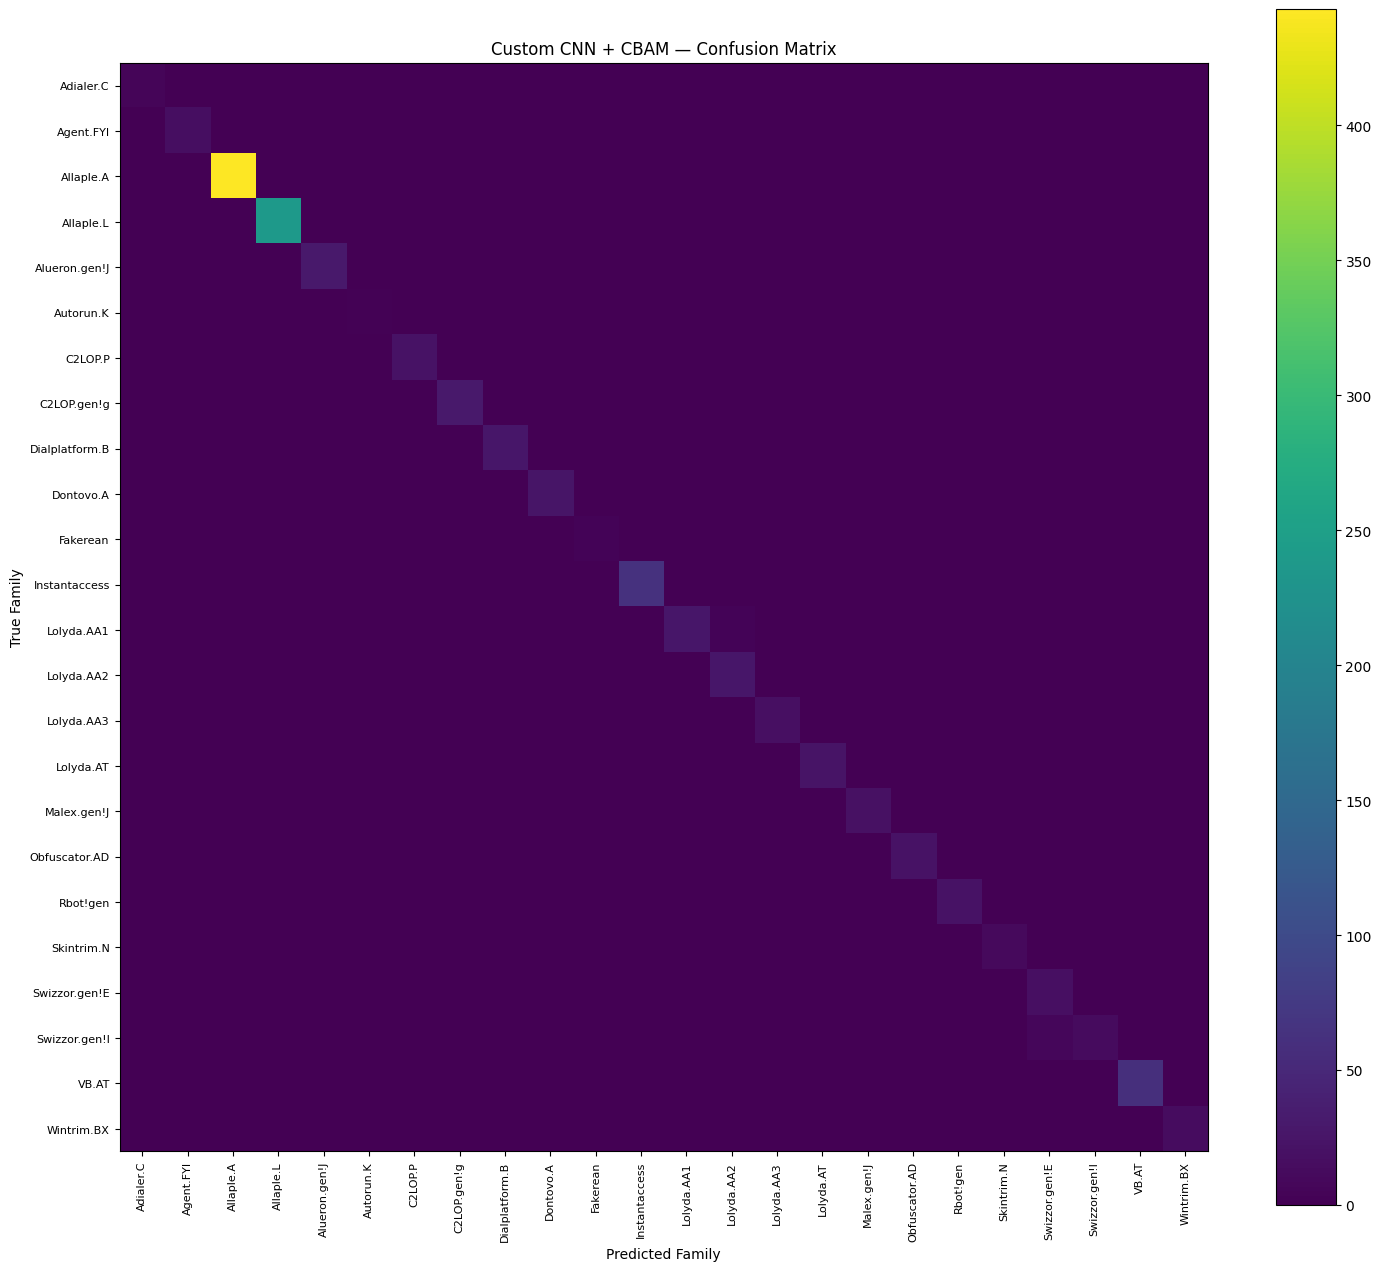


GLOBAL TEST METRICS
----------------------------------------------------------------------------------
Accuracy           : 0.9850
Macro Precision    : 0.9524
Macro Recall       : 0.9690
Macro F1           : 0.9572
Weighted Precision : 0.9867
Weighted Recall    : 0.9850
Weighted F1        : 0.9850

EFFICIENCY
----------------------------------------------------------------------------------
Training time      : 13.77 min
Epochs completed   : 17
Total parameters   : 312,298
Model size         : 3.70 MB
Inference          : 2.9137 ms/image

LOWEST PER-CLASS RECALL
----------------------------------------------------------------------------------
               precision    recall  f1-score  support
family                                               
Swizzor.gen!I   0.866667  0.650000  0.742857     20.0
Lolyda.AA1      0.964286  0.843750  0.900000     32.0
Rbot!gen        1.000000  0.913043  0.954545     23.0
Swizzor.gen!E   0.720000  0.947368  0.818182     19.0
C2LOP.P         1.00000

In [14]:
# ============================================================
# CELL 10
# TRAIN + EVALUATE PROPOSED CUSTOM CNN + CBAM
# ============================================================

print("=" * 88)
print("TRAINING PROPOSED MODEL — CUSTOM CNN + CBAM")
print("=" * 88)

(
    custom_cnn_cbam,
    cbam_history,
    cbam_result,
    cbam_report,
    cbam_per_class,
    cbam_predictions
) = run_proposed_experiment(
    custom_cnn_cbam
)

print("\n" + "=" * 88)
print("CUSTOM CNN + CBAM EXPERIMENT COMPLETE ✓")
print("=" * 88)

In [15]:
# ============================================================
# CELL 11
# DIRECT ATTENTION EFFECT
#
# SimpleCNN vs SAME CNN + CBAM
# ============================================================

print("=" * 88)
print("DIRECT ATTENTION EFFECT")
print("SIMPLE CNN vs SAME CNN + CBAM")
print("=" * 88)

# ------------------------------------------------------------
# LOCKED SimpleCNN result from baseline notebook.
# These are measured experimental results, NOT estimates.
# ------------------------------------------------------------

simple_cnn_result = {

    "model": "SimpleCNN",

    "accuracy": 0.9626,

    "macro_precision": 0.9083,

    "macro_recall": 0.9229,

    "macro_f1": 0.8908,

    "weighted_f1": 0.9581,

    "training_time_minutes": 11.45,

    "total_params": 307960,

    "model_size_mb": 3.64,

    "inference_ms_per_image": 1.9828
}


# ============================================================
# BUILD COMPARISON TABLE
# ============================================================

attention_comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ],

    "SimpleCNN": [
        simple_cnn_result[
            "accuracy"
        ],
        simple_cnn_result[
            "macro_precision"
        ],
        simple_cnn_result[
            "macro_recall"
        ],
        simple_cnn_result[
            "macro_f1"
        ],
        simple_cnn_result[
            "weighted_f1"
        ]
    ],

    "CNN + CBAM": [
        cbam_result[
            "accuracy"
        ],
        cbam_result[
            "macro_precision"
        ],
        cbam_result[
            "macro_recall"
        ],
        cbam_result[
            "macro_f1"
        ],
        cbam_result[
            "weighted_f1"
        ]
    ]
})

attention_comparison[
    "Change"
] = (
    attention_comparison[
        "CNN + CBAM"
    ]
    -
    attention_comparison[
        "SimpleCNN"
    ]
)

attention_display = (
    attention_comparison.copy()
)

for column in [
    "SimpleCNN",
    "CNN + CBAM",
    "Change"
]:

    attention_display[
        column
    ] = (
        attention_display[
            column
        ] * 100
    )

print(
    "\nPerformance comparison:"
)

print(
    attention_display.to_string(
        index=False,
        formatters={
            "SimpleCNN":
                lambda x: f"{x:.2f}%",
            "CNN + CBAM":
                lambda x: f"{x:.2f}%",
            "Change":
                lambda x: f"{x:+.2f} pp"
        }
    )
)

# ============================================================
# ATTENTION EFFECT ON PRIMARY METRIC
# ============================================================

macro_f1_change = (
    cbam_result["macro_f1"]
    -
    simple_cnn_result["macro_f1"]
)

macro_recall_change = (
    cbam_result["macro_recall"]
    -
    simple_cnn_result["macro_recall"]
)

accuracy_change = (
    cbam_result["accuracy"]
    -
    simple_cnn_result["accuracy"]
)

print("\n" + "-" * 88)

print(
    f"Macro-F1 change     : "
    f"{macro_f1_change * 100:+.2f} percentage points"
)

print(
    f"Macro Recall change : "
    f"{macro_recall_change * 100:+.2f} percentage points"
)

print(
    f"Accuracy change     : "
    f"{accuracy_change * 100:+.2f} percentage points"
)

# ============================================================
# SAVE
# ============================================================

attention_comparison_path = (
    OUTPUT_DIR /
    "attention_effect_SimpleCNN_vs_CBAM.csv"
)

attention_comparison.to_csv(
    attention_comparison_path,
    index=False
)

print("\nSaved:")
print(attention_comparison_path)

DIRECT ATTENTION EFFECT
SIMPLE CNN vs SAME CNN + CBAM

Performance comparison:
         Metric SimpleCNN CNN + CBAM   Change
       Accuracy    96.26%     98.50% +2.24 pp
Macro Precision    90.83%     95.24% +4.41 pp
   Macro Recall    92.29%     96.90% +4.61 pp
       Macro F1    89.08%     95.72% +6.64 pp
    Weighted F1    95.81%     98.50% +2.69 pp

----------------------------------------------------------------------------------------
Macro-F1 change     : +6.64 percentage points
Macro Recall change : +4.61 percentage points
Accuracy change     : +2.24 percentage points

Saved:
/kaggle/working/task2_proposed_outputs/attention_effect_SimpleCNN_vs_CBAM.csv


FINAL TASK 2 — ALL MODEL COMPARISON

PERFORMANCE
--------------------------------------------------------------------------------------------
         model accuracy macro_precision macro_recall macro_f1 weighted_f1  macro_f1_rank
CustomCNN_CBAM   98.50%          95.24%       96.90%   95.72%      98.50%              1
EfficientNetB0   96.26%          92.33%       94.79%   92.96%      96.39%              2
   DenseNet121   96.18%          92.91%       92.57%   91.88%      95.90%              3
     SimpleCNN   96.26%          90.83%       92.29%   89.08%      95.81%              4
      ResNet50   94.18%          82.59%       82.72%   80.79%      93.64%              5

EFFICIENCY
--------------------------------------------------------------------------------------------
         model total_params model_size_mb training_time_minutes inference_ms_per_image
CustomCNN_CBAM      312,298          3.70                 13.77                 2.9137
EfficientNetB0    4,216,635         18.18    

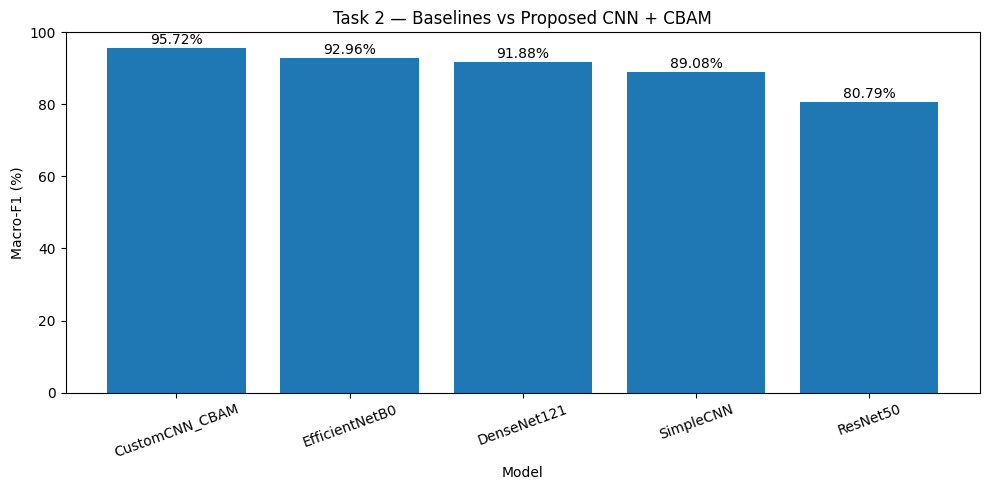


Saved:
/kaggle/working/task2_proposed_outputs/FINAL_Task2_all_model_comparison.csv
/kaggle/working/task2_proposed_outputs/FINAL_all_models_macro_f1.png

ALL-MODEL COMPARISON: COMPLETE ✓


In [16]:
# ============================================================
# CELL 12
# FINAL TASK 2 — ALL MODEL COMPARISON
# ============================================================

print("=" * 92)
print("FINAL TASK 2 — ALL MODEL COMPARISON")
print("=" * 92)

# ------------------------------------------------------------
# LOCKED measured baseline results
# ------------------------------------------------------------

locked_baselines = [

    {
        "model": "SimpleCNN",
        "accuracy": 0.9626,
        "macro_precision": 0.9083,
        "macro_recall": 0.9229,
        "macro_f1": 0.8908,
        "weighted_f1": 0.9581,
        "training_time_minutes": 11.45,
        "total_params": 307960,
        "model_size_mb": 3.64,
        "inference_ms_per_image": 1.9828
    },

    {
        "model": "ResNet50",
        "accuracy": 0.9418,
        "macro_precision": 0.8259,
        "macro_recall": 0.8272,
        "macro_f1": 0.8079,
        "weighted_f1": 0.9364,
        "training_time_minutes": 2.95,
        "total_params": 23853080,
        "model_size_mb": 93.67,
        "inference_ms_per_image": 7.5889
    },

    {
        "model": "DenseNet121",
        "accuracy": 0.9618,
        "macro_precision": 0.9291,
        "macro_recall": 0.9257,
        "macro_f1": 0.9188,
        "weighted_f1": 0.9590,
        "training_time_minutes": 10.13,
        "total_params": 7171800,
        "model_size_mb": 29.85,
        "inference_ms_per_image": 11.1784
    },

    {
        "model": "EfficientNetB0",
        "accuracy": 0.9626,
        "macro_precision": 0.9233,
        "macro_recall": 0.9479,
        "macro_f1": 0.9296,
        "weighted_f1": 0.9639,
        "training_time_minutes": 5.43,
        "total_params": 4216635,
        "model_size_mb": 18.18,
        "inference_ms_per_image": 6.0182
    }
]


# Proposed result
proposed_row = {

    "model":
        "CustomCNN_CBAM",

    "accuracy":
        cbam_result["accuracy"],

    "macro_precision":
        cbam_result["macro_precision"],

    "macro_recall":
        cbam_result["macro_recall"],

    "macro_f1":
        cbam_result["macro_f1"],

    "weighted_f1":
        cbam_result["weighted_f1"],

    "training_time_minutes":
        cbam_result[
            "training_time_minutes"
        ],

    "total_params":
        cbam_result[
            "total_params"
        ],

    "model_size_mb":
        cbam_result[
            "model_size_mb"
        ],

    "inference_ms_per_image":
        cbam_result[
            "inference_ms_per_image"
        ]
}


all_results_df = pd.DataFrame(
    locked_baselines
    + [proposed_row]
)

# ------------------------------------------------------------
# Rank by mandatory primary metric
# ------------------------------------------------------------

all_results_df[
    "macro_f1_rank"
] = (
    all_results_df[
        "macro_f1"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

all_results_df = (
    all_results_df
    .sort_values(
        "macro_f1",
        ascending=False
    )
    .reset_index(drop=True)
)

# ============================================================
# PERFORMANCE TABLE
# ============================================================

display_df = all_results_df.copy()

for col in [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1"
]:

    display_df[col] = (
        display_df[col] * 100
    )

print("\nPERFORMANCE")
print("-" * 92)

print(
    display_df[
        [
            "model",
            "accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "weighted_f1",
            "macro_f1_rank"
        ]
    ].to_string(
        index=False,
        formatters={
            "accuracy":
                lambda x: f"{x:.2f}%",
            "macro_precision":
                lambda x: f"{x:.2f}%",
            "macro_recall":
                lambda x: f"{x:.2f}%",
            "macro_f1":
                lambda x: f"{x:.2f}%",
            "weighted_f1":
                lambda x: f"{x:.2f}%"
        }
    )
)

# ============================================================
# EFFICIENCY
# ============================================================

print("\nEFFICIENCY")
print("-" * 92)

print(
    all_results_df[
        [
            "model",
            "total_params",
            "model_size_mb",
            "training_time_minutes",
            "inference_ms_per_image"
        ]
    ].to_string(
        index=False,
        formatters={
            "total_params":
                lambda x: f"{int(x):,}",
            "model_size_mb":
                lambda x: f"{x:.2f}",
            "training_time_minutes":
                lambda x: f"{x:.2f}",
            "inference_ms_per_image":
                lambda x: f"{x:.4f}"
        }
    )
)

# ============================================================
# BEST MODEL
# ============================================================

best_model = (
    all_results_df.iloc[0]
)

print("\n" + "=" * 92)
print("BEST MODEL BY MACRO-F1")
print("=" * 92)

print(
    "Model        :",
    best_model["model"]
)

print(
    f"Macro-F1     : "
    f"{best_model['macro_f1'] * 100:.2f}%"
)

print(
    f"Macro Recall : "
    f"{best_model['macro_recall'] * 100:.2f}%"
)

print(
    f"Accuracy     : "
    f"{best_model['accuracy'] * 100:.2f}%"
)

# ============================================================
# MACRO-F1 GRAPH
# ============================================================

plot_df = (
    all_results_df
    .sort_values(
        "macro_f1",
        ascending=False
    )
)

plt.figure(
    figsize=(10, 5)
)

bars = plt.bar(
    plot_df["model"],
    plot_df["macro_f1"] * 100
)

plt.ylabel(
    "Macro-F1 (%)"
)

plt.xlabel(
    "Model"
)

plt.title(
    "Task 2 — Baselines vs Proposed CNN + CBAM"
)

plt.ylim(
    0,
    100
)

plt.xticks(
    rotation=20
)

for bar, value in zip(
    bars,
    plot_df["macro_f1"]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value * 100:.2f}%",
        ha="center"
    )

plt.tight_layout()

comparison_graph_path = (
    OUTPUT_DIR /
    "FINAL_all_models_macro_f1.png"
)

plt.savefig(
    comparison_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# SAVE
# ============================================================

comparison_csv_path = (
    OUTPUT_DIR /
    "FINAL_Task2_all_model_comparison.csv"
)

all_results_df.to_csv(
    comparison_csv_path,
    index=False
)

print("\nSaved:")
print(comparison_csv_path)
print(comparison_graph_path)

print("\nALL-MODEL COMPARISON: COMPLETE ✓")

In [17]:
# ============================================================
# CELL 13
# FINAL TASK 2 CONCLUSION
#
# REQUIRED QUESTION:
# "Does attention help?"
# ============================================================

print("=" * 92)
print("TASK 2 FINAL QUESTION — DOES ATTENTION HELP?")
print("=" * 92)

# ============================================================
# DIRECT ATTENTION EFFECT
# ============================================================

simple_macro_f1 = (
    simple_cnn_result[
        "macro_f1"
    ]
)

simple_macro_recall = (
    simple_cnn_result[
        "macro_recall"
    ]
)

simple_accuracy = (
    simple_cnn_result[
        "accuracy"
    ]
)

cbam_macro_f1 = (
    cbam_result[
        "macro_f1"
    ]
)

cbam_macro_recall = (
    cbam_result[
        "macro_recall"
    ]
)

cbam_accuracy = (
    cbam_result[
        "accuracy"
    ]
)


delta_macro_f1 = (
    cbam_macro_f1
    -
    simple_macro_f1
)

delta_macro_recall = (
    cbam_macro_recall
    -
    simple_macro_recall
)

delta_accuracy = (
    cbam_accuracy
    -
    simple_accuracy
)


# ============================================================
# BEST BASELINE
# ============================================================

best_baseline_row = (
    pd.DataFrame(
        locked_baselines
    )
    .sort_values(
        "macro_f1",
        ascending=False
    )
    .iloc[0]
)

best_baseline_name = (
    best_baseline_row[
        "model"
    ]
)

best_baseline_macro_f1 = float(
    best_baseline_row[
        "macro_f1"
    ]
)

delta_best_baseline = (
    cbam_macro_f1
    -
    best_baseline_macro_f1
)


# ============================================================
# INTERPRETATION
# ============================================================

if (
    delta_macro_f1 > 0
    and delta_macro_recall >= 0
):

    attention_verdict = (
        "YES — attention improved the custom CNN "
        "under the primary integrity-aware metrics."
    )

elif delta_macro_f1 > 0:

    attention_verdict = (
        "PARTIALLY — CBAM improved Macro-F1, "
        "but Macro Recall did not improve."
    )

elif (
    delta_macro_f1 <= 0
    and delta_macro_recall > 0
):

    attention_verdict = (
        "MIXED — CBAM improved Macro Recall, "
        "but did not improve Macro-F1."
    )

else:

    attention_verdict = (
        "NO — under this Task 2 configuration, "
        "CBAM did not improve the custom CNN "
        "on the primary metrics."
    )


print("\nDIRECT ATTENTION COMPARISON")
print("-" * 92)

print(
    f"SimpleCNN Macro-F1      : "
    f"{simple_macro_f1 * 100:.2f}%"
)

print(
    f"CNN+CBAM Macro-F1       : "
    f"{cbam_macro_f1 * 100:.2f}%"
)

print(
    f"Macro-F1 change         : "
    f"{delta_macro_f1 * 100:+.2f} pp"
)

print()

print(
    f"SimpleCNN Macro Recall  : "
    f"{simple_macro_recall * 100:.2f}%"
)

print(
    f"CNN+CBAM Macro Recall   : "
    f"{cbam_macro_recall * 100:.2f}%"
)

print(
    f"Macro Recall change     : "
    f"{delta_macro_recall * 100:+.2f} pp"
)

print()

print(
    f"SimpleCNN Accuracy      : "
    f"{simple_accuracy * 100:.2f}%"
)

print(
    f"CNN+CBAM Accuracy       : "
    f"{cbam_accuracy * 100:.2f}%"
)

print(
    f"Accuracy change         : "
    f"{delta_accuracy * 100:+.2f} pp"
)


print("\n" + "=" * 92)
print("ATTENTION VERDICT")
print("=" * 92)

print(attention_verdict)


print("\n" + "=" * 92)
print("PROPOSED MODEL vs BEST CNN BASELINE")
print("=" * 92)

print(
    f"Best baseline           : "
    f"{best_baseline_name}"
)

print(
    f"Best baseline Macro-F1  : "
    f"{best_baseline_macro_f1 * 100:.2f}%"
)

print(
    f"CNN+CBAM Macro-F1       : "
    f"{cbam_macro_f1 * 100:.2f}%"
)

print(
    f"Difference              : "
    f"{delta_best_baseline * 100:+.2f} pp"
)


# ============================================================
# SAVE FINAL CONCLUSION
# ============================================================

final_summary = {

    "question":
        "Does attention help?",

    "simple_cnn_macro_f1":
        float(simple_macro_f1),

    "cbam_macro_f1":
        float(cbam_macro_f1),

    "macro_f1_change":
        float(delta_macro_f1),

    "simple_cnn_macro_recall":
        float(simple_macro_recall),

    "cbam_macro_recall":
        float(cbam_macro_recall),

    "macro_recall_change":
        float(delta_macro_recall),

    "simple_cnn_accuracy":
        float(simple_accuracy),

    "cbam_accuracy":
        float(cbam_accuracy),

    "accuracy_change":
        float(delta_accuracy),

    "best_baseline":
        best_baseline_name,

    "best_baseline_macro_f1":
        float(
            best_baseline_macro_f1
        ),

    "cbam_vs_best_baseline_macro_f1_change":
        float(
            delta_best_baseline
        ),

    "attention_verdict":
        attention_verdict
}

final_summary_path = (
    OUTPUT_DIR /
    "FINAL_Task2_attention_conclusion.json"
)

with open(
    final_summary_path,
    "w"
) as f:

    json.dump(
        final_summary,
        f,
        indent=4
    )

print("\nSaved:")
print(final_summary_path)

print("\n" + "=" * 92)
print("TRACK 3 — TASK 2 EXPERIMENTS COMPLETE ✓")
print("=" * 92)

TASK 2 FINAL QUESTION — DOES ATTENTION HELP?

DIRECT ATTENTION COMPARISON
--------------------------------------------------------------------------------------------
SimpleCNN Macro-F1      : 89.08%
CNN+CBAM Macro-F1       : 95.72%
Macro-F1 change         : +6.64 pp

SimpleCNN Macro Recall  : 92.29%
CNN+CBAM Macro Recall   : 96.90%
Macro Recall change     : +4.61 pp

SimpleCNN Accuracy      : 96.26%
CNN+CBAM Accuracy       : 98.50%
Accuracy change         : +2.24 pp

ATTENTION VERDICT
YES — attention improved the custom CNN under the primary integrity-aware metrics.

PROPOSED MODEL vs BEST CNN BASELINE
Best baseline           : EfficientNetB0
Best baseline Macro-F1  : 92.96%
CNN+CBAM Macro-F1       : 95.72%
Difference              : +2.76 pp

Saved:
/kaggle/working/task2_proposed_outputs/FINAL_Task2_attention_conclusion.json

TRACK 3 — TASK 2 EXPERIMENTS COMPLETE ✓
